In [1]:
import pandas as pd
import polars as pl
from pathlib import Path

In [ ]:
# first_event_time, last_event_time = all_coins_kalshi.select(pl.col('open_time').min(), pl.col('close_time').max()).row(0)

# all_coins_kalshi = all_coins_kalshi.filter(~((pl.col("open_time") == first_event_time) | (pl.col("close_time") == last_event_time)))
# all_coins_kalshi.head()
# all_coins_kalshi.group_by(('open_time')).agg(pl.len()).sort('open_time')


In [3]:
# raw_data_dir = Path.cwd().parent / 'data_gather' / 'raw_data'
filtered_data_dir = Path.cwd().parent / 'data_gather' / 'filtered_data'


In [4]:
# trades = pl.scan_csv(raw_data_dir / 'coinbase_trades.csv').collect()
# options = pl.scan_csv(raw_data_dir / 'deribit_option_vols.csv').collect()
# kalshi = pl.scan_csv(raw_data_dir / 'kalshi_markets.csv').collect()
# polymarket = pl.scan_csv(raw_data_dir / 'polymarket_markets.csv').collect()

In [5]:
class filter_data(): 
    def __init__(self
                 , trades: pl.DataFrame
                 , options: pl.DataFrame
                 , kalshi: pl.DataFrame
                 , polymarket: pl.DataFrame):
        
        self.trades = trades
        self.options = options
        self.kalshi = kalshi
        self.polymarket = polymarket
    
    def clean_trades(self, coins: list) -> pl.DataFrame:
        coin_trades = self.trades.filter(pl.col('product_id').is_in([f'{coin}-USD' for coin in coins]))
        coin_trades = coin_trades.unique(subset=['trade_id'])
        coin_trades = coin_trades.sort('trade_time', descending=False)
        coin_trades = coin_trades.drop('id').with_row_index('id')
        coin_trades = coin_trades.select('id', 'curr_time', 'product_id', 'trade_time', 'price', 'size', 'side')
        return coin_trades
    
    def clean_options(self, coins: list) -> pl.DataFrame: 
        coin_options = self.options.filter(pl.col('currency').is_in([f'{coin}' for coin in coins]))
        coin_options = coin_options.sort('curr_time', descending=False)
        coin_options = coin_options.drop('id').with_row_index('id')
        coin_options = coin_options.select('id', 'curr_time', 'instrument_name', 'expiry_datetime', 'strike', 
                                           'option_type', 'underlying_price', 'delta', 'mark_iv', 'mark_price', 
                                           'open_interest', 'volume')
        return coin_options
    
    def clean_kalshi(self, coins: list) -> pl.DataFrame: 
        coin_kalshi = self.kalshi.filter(pl.col('coin').is_in([f'{coin}' for coin in coins]))
        coin_kalshi = coin_kalshi.sort('curr_time', descending=False)
        coin_kalshi = coin_kalshi.drop('id').with_row_index('id')
        coin_kalshi = coin_kalshi.select('id', 'curr_time', 'coin', 'open_time', 'close_time', 
                                         'last_price_dollars' , 'no_ask_dollars', 'no_bid_dollars', 
                                         'yes_ask_dollars', 'yes_bid_dollars', 'floor_strike', 'volume_24h_fp')
        return coin_kalshi
    
    def clean_polymarket(self, coins: list) -> pl.DataFrame:
        coin_polymarket = self.polymarket.filter(pl.col('coin').is_in([f'{coin}' for coin in coins]))
        coin_polymarket = coin_polymarket.sort('curr_time', descending=False)
        coin_polymarket = coin_polymarket.drop('id').with_row_index('id')
        coin_polymarket = coin_polymarket.select('id', 'curr_time', 'coin', 'interval_start_unix', 'end_date', 'strike_price',
                                                 'liquidity', 'volume', 'yes_implied_price', 'no_implied_price', 'yes_buy_price',
                                                 'yes_sell_price', 'no_buy_price', 'no_sell_price')
        return coin_polymarket
    
        

In [6]:
# FILTERER = filter_data(trades=trades, options=options, kalshi=kalshi, polymarket=polymarket)


In [7]:
# btc_trades = FILTERER.clean_trades(['BTC'])
# btc_eth_options = FILTERER.clean_options(['BTC', 'ETH'])
# all_coins_kalshi = FILTERER.clean_kalshi(['BTC', 'ETH', 'XRP', 'SOL'])
# all_coins_polymarket = FILTERER.clean_polymarket(['BTC', 'ETH', 'XRP', 'SOL'])

In [26]:
btc_trades = pl.scan_csv(filtered_data_dir / 'btc_trades.csv').collect()
btc_eth_options = pl.scan_csv(filtered_data_dir / 'btc_eth_options.csv').collect()
all_coins_kalshi = pl.scan_csv(filtered_data_dir / 'all_kalshi.csv').collect()
all_coins_polymarket = pl.scan_csv(filtered_data_dir / 'all_polymarket.csv').collect()

In [27]:
def _to_datetime(table: pl.DataFrame, cols: list) -> pl.DataFrame:
    for col in cols: 
        table = table.with_columns(
            pl.col(col)
            .str.to_datetime(format="%Y-%m-%d %H:%M:%S%.f%#z", strict=False)
            .alias(col)
        )
    return table


In [28]:
btc_trades = _to_datetime(btc_trades, ['curr_time', 'trade_time'])
btc_eth_options = _to_datetime(btc_eth_options, ['curr_time', 'expiry_datetime'])
all_coins_kalshi = _to_datetime(all_coins_kalshi, ['curr_time', 'open_time', 'close_time'])
all_coins_polymarket = _to_datetime(all_coins_polymarket, ['curr_time', 'end_date'])


In [147]:


all_coins_kalshi = all_coins_kalshi.with_columns((pl.col('close_time') - pl.col('curr_time')).dt.total_seconds().alias('time_to_close'))
all_coins_kalshi = all_coins_kalshi.unique(subset=["coin", "open_time", "close_time", "time_to_close"], keep="first").sort(["coin", "curr_time", "open_time", "close_time"])

btc_kalshi = all_coins_kalshi.filter(pl.col('coin') == 'BTC').filter(pl.col('time_to_close') >= 0)
btc_kalshi = btc_kalshi.with_columns(
    pl.col("curr_time").shift(1).over(["coin", "open_time", "close_time"]).alias("prev_time")
).with_columns(
    (pl.col("curr_time") - pl.col("prev_time"))
    .dt.total_seconds()
    .alias("time_diff_seconds")
)

btc_kalshi = btc_kalshi.filter(pl.col("time_diff_seconds").is_between(0.9, 1.1))
# df['time_diff_seconds'].value_counts()

btc_kalshi = btc_kalshi.join_asof(btc_trades[['trade_time', 'price']], left_on='curr_time', right_on='trade_time', strategy='backward')
# btc_kalshi = btc_kalshi.drop(['trade_time', 'time_diff_seconds', 'prev_time'])
btc_kalshi = btc_kalshi.with_columns(
    (pl.col("price") - pl.col("floor_strike")).alias("distance_from_strike")
)

btc_kalshi = btc_kalshi.with_columns(((pl.col('yes_ask_dollars') + pl.col('yes_bid_dollars'))/2).alias('yes_mid_dollars'))

outcome_map = (
    btc_kalshi
    .sort("curr_time")
    .group_by(['open_time', 'close_time'])
    .agg(
        pl.col("yes_mid_dollars").last().alias("last_mid_dollars")
    )
    .with_columns(
        (pl.col("last_mid_dollars") > 0.5).cast(pl.Int8).alias("outcome")
    )
    .select(["open_time", "close_time", "outcome"])
)

btc_kalshi = btc_kalshi.join(outcome_map, left_on=['open_time', 'close_time'], right_on=['open_time', 'close_time'], how='left')
btc_kalshi.head(10)

btc_kalshi.filter(pl.col('time_to_close') == 0)
# btc_kalshi.filter((pl.col("time_to_close") == 0) & (((pl.col("outcome") == 0) & (pl.col("price") > 0)) | ((pl.col("outcome") == 1) & (pl.col("price") < 0)))).height
btc_kalshi.filter(pl.col('time_to_close') == 0)


id,curr_time,coin,open_time,close_time,last_price_dollars,no_ask_dollars,no_bid_dollars,yes_ask_dollars,yes_bid_dollars,floor_strike,volume_24h_fp,time_to_close,prev_time,time_diff_seconds,trade_time,price,distance_from_strike,yes_mid_dollars,outcome
i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,i64,"datetime[μs, UTC]",i64,"datetime[μs, UTC]",f64,f64,f64,i8
2972,2026-03-21 10:59:59.239146 UTC,"""BTC""",2026-03-21 10:45:00 UTC,2026-03-21 11:00:00 UTC,0.999,0.001,0.0,1.0,0.999,70581.15,30161.0,0,2026-03-21 10:59:58.163443 UTC,1,2026-03-21 10:59:58.863053 UTC,70596.47,15.32,0.9995,1
6552,2026-03-21 11:14:59.620753 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.001,1.0,0.999,0.001,0.0,70592.55,133450.0,0,2026-03-21 11:14:58.619237 UTC,1,2026-03-21 11:14:59.059261 UTC,70557.06,-35.49,0.0005,0
10124,2026-03-21 11:29:59.682933 UTC,"""BTC""",2026-03-21 11:15:00 UTC,2026-03-21 11:30:00 UTC,0.998,0.002,0.001,0.999,0.998,70571.47,28957.0,0,2026-03-21 11:29:58.682209 UTC,1,2026-03-21 11:29:58.750759 UTC,70595.03,23.56,0.9985,1
13696,2026-03-21 11:44:59.019633 UTC,"""BTC""",2026-03-21 11:30:00 UTC,2026-03-21 11:45:00 UTC,0.993,0.004,0.001,0.999,0.996,70597.99,68663.0,0,2026-03-21 11:44:58.018742 UTC,1,2026-03-21 11:44:58.098317 UTC,70631.24,33.25,0.9975,1
17260,2026-03-21 11:59:59.744650 UTC,"""BTC""",2026-03-21 11:45:00 UTC,2026-03-21 12:00:00 UTC,0.999,0.001,0.0,1.0,0.999,70633.61,24640.0,0,2026-03-21 11:59:58.743755 UTC,1,2026-03-21 11:59:59.399763 UTC,70637.76,4.15,0.9995,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4183639,2026-04-03 00:29:59.787492 UTC,"""BTC""",2026-04-03 00:15:00 UTC,2026-04-03 00:30:00 UTC,0.89,0.1,0.025,0.975,0.9,66826.509999,44381.53,0,2026-04-03 00:29:58.785780 UTC,1,2026-04-03 00:29:59.693184 UTC,66822.71,-3.799999,0.9375,1
4187271,2026-04-03 00:44:59.230407 UTC,"""BTC""",2026-04-03 00:30:00 UTC,2026-04-03 00:45:00 UTC,0.009,0.999,0.991,0.009,0.001,66831.83,166074.39,0,2026-04-03 00:44:58.230150 UTC,1,2026-04-03 00:44:58.882381 UTC,66802.01,-29.82,0.005,0
4190803,2026-04-03 00:59:59.834055 UTC,"""BTC""",2026-04-03 00:45:00 UTC,2026-04-03 01:00:00 UTC,0.007,1.0,0.999,0.001,0.0,66819.53,88753.65,0,2026-04-03 00:59:58.833731 UTC,1,2026-04-03 00:59:59.215998 UTC,66783.9,-35.63,0.0005,0


In [151]:
feature_cols = [
    "curr_time",
    "last_price_dollars",
    "yes_bid_dollars",
    "yes_ask_dollars",
    "no_bid_dollars",
    "no_ask_dollars",
    "yes_mid_dollars",
    "spread_dollars",
    "cross_sum_mid",
    "time_to_close",
    "floor_strike",
]

def build_coin_df(df: pl.DataFrame, coin: str) -> pl.DataFrame:
    return (
        df
        .filter((pl.col("coin") == coin) & (pl.col("time_to_close") >= 0))
        .with_columns([
            ((pl.col("yes_ask_dollars") + pl.col("yes_bid_dollars")) / 2).alias("yes_mid_dollars"),
            (pl.col("yes_ask_dollars") - pl.col("yes_bid_dollars")).alias("spread_dollars"),
            (
                ((pl.col("yes_ask_dollars") + pl.col("yes_bid_dollars")) / 2) +
                ((pl.col("no_ask_dollars") + pl.col("no_bid_dollars")) / 2)
            ).alias("cross_sum_mid"),
        ])
        .select(feature_cols)
        .rename({
            col: f"{coin}_{col}"
            for col in feature_cols
            if col != "curr_time"
        })
        .sort("curr_time")
    )

eth_kalshi = build_coin_df(all_coins_kalshi, "ETH")
xrp_kalshi = build_coin_df(all_coins_kalshi, "XRP")
sol_kalshi = build_coin_df(all_coins_kalshi, "SOL")

combined = (
    btc_kalshi
    .sort("curr_time")
    .join_asof(eth_kalshi.sort("curr_time"), on="curr_time", strategy="backward", tolerance="2s")
    .join_asof(xrp_kalshi.sort("curr_time"), on="curr_time", strategy="backward", tolerance="2s")
    .join_asof(sol_kalshi.sort("curr_time"), on="curr_time", strategy="backward", tolerance="2s")
)

combined.head()


id,curr_time,coin,open_time,close_time,last_price_dollars,no_ask_dollars,no_bid_dollars,yes_ask_dollars,yes_bid_dollars,floor_strike,volume_24h_fp,time_to_close,prev_time,time_diff_seconds,trade_time,price,distance_from_strike,yes_mid_dollars,outcome,ETH_last_price_dollars,ETH_yes_bid_dollars,ETH_yes_ask_dollars,ETH_no_bid_dollars,ETH_no_ask_dollars,ETH_yes_mid_dollars,ETH_spread_dollars,ETH_cross_sum_mid,ETH_time_to_close,ETH_floor_strike,XRP_last_price_dollars,XRP_yes_bid_dollars,XRP_yes_ask_dollars,XRP_no_bid_dollars,XRP_no_ask_dollars,XRP_yes_mid_dollars,XRP_spread_dollars,XRP_cross_sum_mid,XRP_time_to_close,XRP_floor_strike,SOL_last_price_dollars,SOL_yes_bid_dollars,SOL_yes_ask_dollars,SOL_no_bid_dollars,SOL_no_ask_dollars,SOL_yes_mid_dollars,SOL_spread_dollars,SOL_cross_sum_mid,SOL_time_to_close,SOL_floor_strike
i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,i64,"datetime[μs, UTC]",i64,"datetime[μs, UTC]",f64,f64,f64,i8,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
4,2026-03-21 10:47:33.863137 UTC,"""BTC""",2026-03-21 10:45:00 UTC,2026-03-21 11:00:00 UTC,0.41,0.6,0.58,0.42,0.4,70581.15,0.0,746,2026-03-21 10:47:32.862397 UTC,1,2026-03-21 10:47:33.846121 UTC,70565.43,-15.72,0.41,1,0.28,0.26,0.29,0.71,0.74,0.275,0.03,1.0,746,2155.19,0.34,0.32,0.35,0.65,0.68,0.335,0.03,1.0,746,1.4405,0.22,0.3,0.33,0.67,0.7,0.315,0.03,1.0,746,89.9788
8,2026-03-21 10:47:34.863913 UTC,"""BTC""",2026-03-21 10:45:00 UTC,2026-03-21 11:00:00 UTC,0.41,0.6,0.58,0.42,0.4,70581.15,0.0,745,2026-03-21 10:47:33.863137 UTC,1,2026-03-21 10:47:34.341182 UTC,70565.43,-15.72,0.41,1,0.28,0.26,0.29,0.71,0.74,0.275,0.03,1.0,745,2155.19,0.34,0.32,0.35,0.65,0.68,0.335,0.03,1.0,745,1.4405,0.22,0.3,0.33,0.67,0.7,0.315,0.03,1.0,745,89.9788
12,2026-03-21 10:47:35.864626 UTC,"""BTC""",2026-03-21 10:45:00 UTC,2026-03-21 11:00:00 UTC,0.41,0.6,0.58,0.42,0.4,70581.15,0.0,744,2026-03-21 10:47:34.863913 UTC,1,2026-03-21 10:47:35.759990 UTC,70565.43,-15.72,0.41,1,0.28,0.26,0.29,0.71,0.74,0.275,0.03,1.0,744,2155.19,0.34,0.32,0.35,0.65,0.68,0.335,0.03,1.0,744,1.4405,0.22,0.3,0.33,0.67,0.7,0.315,0.03,1.0,744,89.9788
16,2026-03-21 10:47:36.866221 UTC,"""BTC""",2026-03-21 10:45:00 UTC,2026-03-21 11:00:00 UTC,0.41,0.6,0.58,0.42,0.4,70581.15,0.0,743,2026-03-21 10:47:35.864626 UTC,1,2026-03-21 10:47:36.847918 UTC,70565.43,-15.72,0.41,1,0.28,0.26,0.29,0.71,0.74,0.275,0.03,1.0,743,2155.19,0.34,0.32,0.35,0.65,0.68,0.335,0.03,1.0,743,1.4405,0.22,0.3,0.33,0.67,0.7,0.315,0.03,1.0,743,89.9788
20,2026-03-21 10:47:37.866620 UTC,"""BTC""",2026-03-21 10:45:00 UTC,2026-03-21 11:00:00 UTC,0.41,0.6,0.58,0.42,0.4,70581.15,0.0,742,2026-03-21 10:47:36.866221 UTC,1,2026-03-21 10:47:37.565781 UTC,70565.42,-15.73,0.41,1,0.28,0.22,0.23,0.77,0.78,0.225,0.01,1.0,742,2155.19,0.34,0.32,0.35,0.65,0.68,0.335,0.03,1.0,742,1.4405,0.22,0.3,0.33,0.67,0.7,0.315,0.03,1.0,742,89.9788


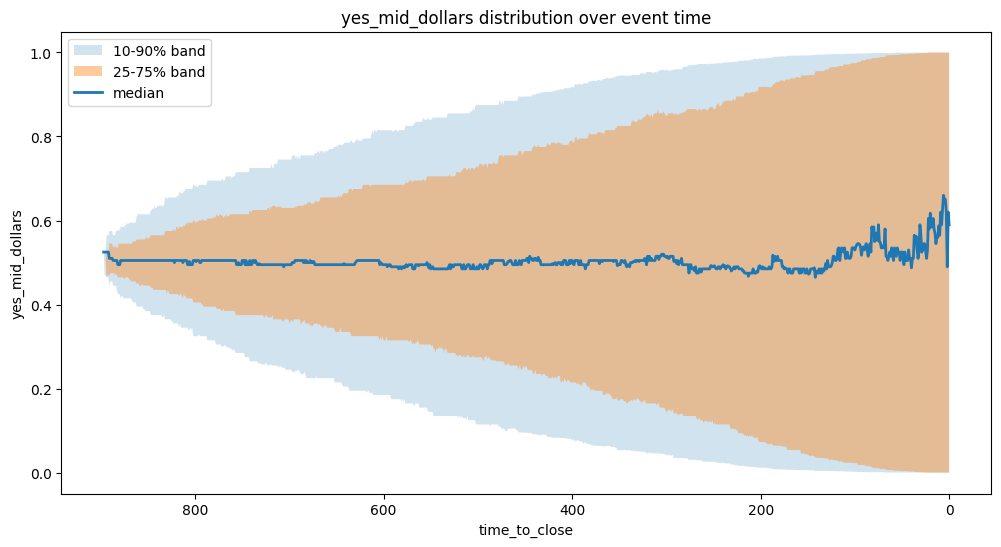

In [150]:
import matplotlib.pyplot as plt
import polars as pl

feature = "yes_mid_dollars"

summary = (
    btc_kalshi
    .filter(pl.col(feature).is_not_null())
    .group_by("time_to_close")
    .agg([
        pl.col(feature).median().alias("median"),
        pl.col(feature).quantile(0.10).alias("q10"),
        pl.col(feature).quantile(0.25).alias("q25"),
        pl.col(feature).quantile(0.75).alias("q75"),
        pl.col(feature).quantile(0.90).alias("q90"),
    ])
    .sort("time_to_close")
)

x = summary["time_to_close"].to_numpy()
median = summary["median"].to_numpy()
q10 = summary["q10"].to_numpy()
q25 = summary["q25"].to_numpy()
q75 = summary["q75"].to_numpy()
q90 = summary["q90"].to_numpy()

plt.figure(figsize=(12, 6))
plt.fill_between(x, q10, q90, alpha=0.2, label="10-90% band")
plt.fill_between(x, q25, q75, alpha=0.4, label="25-75% band")
plt.plot(x, median, linewidth=2, label="median")
plt.gca().invert_xaxis()
plt.xlabel("time_to_close")
plt.ylabel(feature)
plt.title(f"{feature} distribution over event time")
plt.legend()
plt.show()


In [ ]:
def build_coin_df(df: pl.DataFrame, coin: str) -> pl.DataFrame:
    col_identifiers = ["open_time", "close_time"]

    df = (
        df
        .filter(pl.col("coin") == coin)
        .sort(col_identifiers + ["curr_time"])
        .with_columns(
            pl.col("last_price_dollars")
            .shift(-1)
            .over(col_identifiers)
            .alias("next_price_dollars_lead1")
        )
    )
    cols = [col for col in df.columns]

    rename_map = {
        col: f"{coin}_{col}"
        for col in cols
    }

    df = df.rename(rename_map)

    return df

kalshi = kalshi.with_columns((pl.col('close_time') - pl.col('curr_time')).dt.total_seconds().alias('time_to_close'))

kalshi = kalshi.filter(pl.col('time_to_close') > 0)

coin_dfs = [build_coin_df(kalshi, coin) for coin in [ "ETH", "XRP", "SOL"]]

combined = coin_dfs[0]

for next_df in coin_dfs[1:]:
    combined = combined.join(
        next_df,
        on='curr_time',
        how="left",
    )

combined = combined.filter(
    pl.col("BTC_next_price_dollars_lead1").is_not_null()
)

drop_cols = [col for col in ["BTC_coin", "ETH_coin", "XRP_coin", "SOL_coin"] if col in combined.columns]
combined = combined.drop(drop_cols)

outcome_map = (
    combined
    .sort("curr_time")
    .group_by("BTC_open_time")
    .agg(
        pl.col("BTC_last_price_dollars").last().alias("last_btc_price")
    )
    .with_columns(
        (pl.col("last_btc_price") > 0.5).cast(pl.Int8).alias("outcome")
    )
    .select(["BTC_open_time", "outcome"])
)

combined = combined.join(outcome_map, on="BTC_open_time", how="left")
combined.columns


['BTC_id',
 'curr_time',
 'BTC_open_time',
 'BTC_close_time',
 'BTC_last_price_dollars',
 'BTC_no_ask_dollars',
 'BTC_no_bid_dollars',
 'BTC_yes_ask_dollars',
 'BTC_yes_bid_dollars',
 'BTC_floor_strike',
 'BTC_volume_24h_fp',
 'BTC_prev_time',
 'BTC_time_diff_seconds',
 'BTC_time_to_close',
 'BTC_next_price_dollars_lead1',
 'ETH_id',
 'ETH_open_time',
 'ETH_close_time',
 'ETH_last_price_dollars',
 'ETH_no_ask_dollars',
 'ETH_no_bid_dollars',
 'ETH_yes_ask_dollars',
 'ETH_yes_bid_dollars',
 'ETH_floor_strike',
 'ETH_volume_24h_fp',
 'ETH_prev_time',
 'ETH_time_diff_seconds',
 'ETH_time_to_close',
 'ETH_next_price_dollars_lead1',
 'XRP_id',
 'XRP_open_time',
 'XRP_close_time',
 'XRP_last_price_dollars',
 'XRP_no_ask_dollars',
 'XRP_no_bid_dollars',
 'XRP_yes_ask_dollars',
 'XRP_yes_bid_dollars',
 'XRP_floor_strike',
 'XRP_volume_24h_fp',
 'XRP_prev_time',
 'XRP_time_diff_seconds',
 'XRP_time_to_close',
 'XRP_next_price_dollars_lead1',
 'SOL_id',
 'SOL_open_time',
 'SOL_close_time',
 'SOL

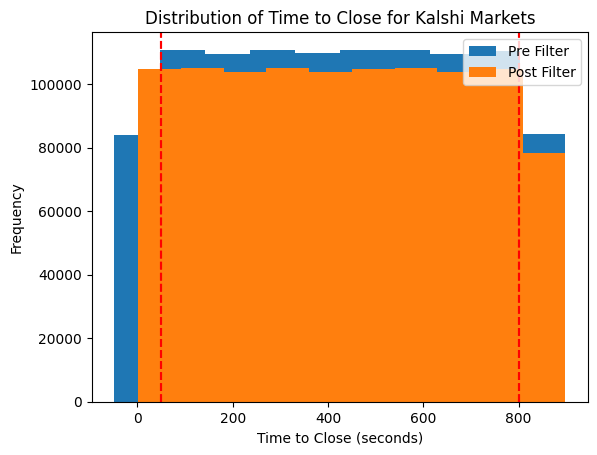

In [87]:
import matplotlib.pyplot as plt 


plt.hist(all_coins_kalshi.filter(pl.col('coin') == 'BTC')['time_to_close'], label='Pre Filter')
plt.axvline(800, color='red', linestyle='--')
plt.axvline(50, color='red', linestyle='--')
plt.xlabel('Time to Close (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Close for Kalshi Markets')



plt.hist(combined['BTC_time_to_close'], label='Post Filter')
plt.axvline(800, color='red', linestyle='--')
plt.axvline(50, color='red', linestyle='--')
plt.xlabel('Time to Close (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Close for Kalshi Markets')

plt.legend()

In [ ]:
combined.sort('curr_time')

BTC_id,curr_time,BTC_open_time,BTC_close_time,BTC_last_price_dollars,BTC_no_ask_dollars,BTC_no_bid_dollars,BTC_yes_ask_dollars,BTC_yes_bid_dollars,BTC_floor_strike,BTC_volume_24h_fp,BTC_prev_time,BTC_time_diff_seconds,BTC_time_to_close,BTC_next_price_dollars_lead1,ETH_id,ETH_open_time,ETH_close_time,ETH_last_price_dollars,ETH_no_ask_dollars,ETH_no_bid_dollars,ETH_yes_ask_dollars,ETH_yes_bid_dollars,ETH_floor_strike,ETH_volume_24h_fp,ETH_prev_time,ETH_time_diff_seconds,ETH_time_to_close,ETH_next_price_dollars_lead1,XRP_id,XRP_open_time,XRP_close_time,XRP_last_price_dollars,XRP_no_ask_dollars,XRP_no_bid_dollars,XRP_yes_ask_dollars,XRP_yes_bid_dollars,XRP_floor_strike,XRP_volume_24h_fp,XRP_prev_time,XRP_time_diff_seconds,XRP_time_to_close,XRP_next_price_dollars_lead1,SOL_id,SOL_open_time,SOL_close_time,SOL_last_price_dollars,SOL_no_ask_dollars,SOL_no_bid_dollars,SOL_yes_ask_dollars,SOL_yes_bid_dollars,SOL_floor_strike,SOL_volume_24h_fp,SOL_prev_time,SOL_time_diff_seconds,SOL_time_to_close,SOL_next_price_dollars_lead1
i64,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64
3156,2026-03-21 11:00:45.584324 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.53,3157,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.0,3158,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.47,3159,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.51
3160,2026-03-21 11:00:46.585918 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.53,3161,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.0,3162,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.47,3163,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.51
3164,2026-03-21 11:00:47.588320 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.53,3165,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.0,3166,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.47,3167,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.51
3168,2026-03-21 11:00:48.591911 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.53,3169,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.0,3170,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.47,3171,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.51
3172,2026-03-21 11:00:49.614644 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:48.591911 UTC,1,850,0.53,3173,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:48.591911 UTC,1,850,0.0,3174,2026-03-21 11:00:00 

In [ ]:
btc_trades.head()

id,curr_time,product_id,trade_time,price,size,side
i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]",f64,f64,str
0,2026-03-21 10:47:31.458355 UTC,"""BTC-USD""",2026-03-21 10:47:31.433808 UTC,70565.43,0.000084,"""sell"""
1,2026-03-21 10:47:31.573966 UTC,"""BTC-USD""",2026-03-21 10:47:31.554989 UTC,70565.43,4.4000e-7,"""sell"""
2,2026-03-21 10:47:32.156989 UTC,"""BTC-USD""",2026-03-21 10:47:32.151470 UTC,70565.43,0.0001403,"""sell"""
3,2026-03-21 10:47:32.673739 UTC,"""BTC-USD""",2026-03-21 10:47:32.669946 UTC,70565.43,4.4000e-7,"""sell"""
4,2026-03-21 10:47:33.706974 UTC,"""BTC-USD""",2026-03-21 10:47:33.701132 UTC,70565.43,0.000511,"""sell"""


In [ ]:
btc_kalshi_trades = combined.join_where(
    btc_trades,
    (pl.col("trade_time") >= pl.col("BTC_prev_time")) &
    (pl.col("trade_time") <= pl.col("curr_time"))
)



trade_features = (
    btc_kalshi_trades
    .with_columns([
        pl.when(pl.col("side") == "buy").then(pl.col("size")).otherwise(0).alias("buy_size"),
        pl.when(pl.col("side") == "sell").then(pl.col("size")).otherwise(0).alias("sell_size"),
        (pl.col("price") * pl.col("size")).alias("dollar_volume"),
    ])
    .group_by("curr_time")
    .agg([
        pl.len().alias("trade_count"),
        pl.col("size").sum().alias("size_sum"),
        pl.col("buy_size").sum().alias("buy_size_sum"),
        pl.col("sell_size").sum().alias("sell_size_sum"),
        (pl.col("buy_size").sum() - pl.col("sell_size").sum()).alias("size_imbalance"),
        pl.col("price").mean().alias("price_mean"),
        pl.col("price").std().alias("price_std"),
        (pl.col("dollar_volume").sum() / pl.col("size").sum()).alias("vwap"),
    ])
)


In [ ]:
kalshi.filter(
    (pl.col("open_time") == pl.datetime(2026, 3, 21, 11, 0, 0, time_zone="UTC")) & (pl.col('coin') == 'BTC')
)


id,curr_time,coin,open_time,close_time,last_price_dollars,no_ask_dollars,no_bid_dollars,yes_ask_dollars,yes_bid_dollars,floor_strike,volume_24h_fp,prev_time,time_diff_seconds,time_to_close
i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64
3036,2026-03-21 11:00:15.418105 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:14.416887 UTC,1,884
3040,2026-03-21 11:00:16.419216 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:15.418105 UTC,1,883
3044,2026-03-21 11:00:17.420444 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:16.419216 UTC,1,882
3048,2026-03-21 11:00:18.421119 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:17.420444 UTC,1,881
3052,2026-03-21 11:00:19.422934 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:18.421119 UTC,1,880
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6540,2026-03-21 11:14:56.617700 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.001,1.0,0.999,0.001,0.0,70592.55,133450.0,2026-03-21 11:14:55.616276 UTC,1,3
6544,2026-03-21 11:14:57.618403 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.001,1.0,0.999,0.001,0.0,70592.55,133450.0,2026-03-21 11:14:56.617700 UTC,1,2
6548,2026-03-21 11:14:58.619237 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.001,1.0,0.999,0.001,0.0,70592.55,133450.0,2026-03-21 11:14:57.618403 UTC,1,1


In [ ]:
btc_kalshi_trades.sort('curr_time')


BTC_id,curr_time,BTC_open_time,BTC_close_time,BTC_last_price_dollars,BTC_no_ask_dollars,BTC_no_bid_dollars,BTC_yes_ask_dollars,BTC_yes_bid_dollars,BTC_floor_strike,BTC_volume_24h_fp,BTC_prev_time,BTC_time_diff_seconds,BTC_time_to_close,BTC_next_price_dollars_lead1,ETH_id,ETH_open_time,ETH_close_time,ETH_last_price_dollars,ETH_no_ask_dollars,ETH_no_bid_dollars,ETH_yes_ask_dollars,ETH_yes_bid_dollars,ETH_floor_strike,ETH_volume_24h_fp,ETH_prev_time,ETH_time_diff_seconds,ETH_time_to_close,ETH_next_price_dollars_lead1,XRP_id,XRP_open_time,XRP_close_time,XRP_last_price_dollars,XRP_no_ask_dollars,XRP_no_bid_dollars,XRP_yes_ask_dollars,XRP_yes_bid_dollars,XRP_floor_strike,XRP_volume_24h_fp,XRP_prev_time,XRP_time_diff_seconds,XRP_time_to_close,XRP_next_price_dollars_lead1,SOL_id,SOL_open_time,SOL_close_time,SOL_last_price_dollars,SOL_no_ask_dollars,SOL_no_bid_dollars,SOL_yes_ask_dollars,SOL_yes_bid_dollars,SOL_floor_strike,SOL_volume_24h_fp,SOL_prev_time,SOL_time_diff_seconds,SOL_time_to_close,SOL_next_price_dollars_lead1,outcome,id,curr_time_right,product_id,trade_time,price,size,side
i64,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i8,i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]",f64,f64,str
3156,2026-03-21 11:00:45.584324 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.53,3157,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.0,3158,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.47,3159,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.51,0,2009,2026-03-21 11:00:44.843820 UTC,"""BTC-USD""",2026-03-21 11:00:44.839260 UTC,70591.61,0.00014,"""sell"""
3168,2026-03-21 11:00:48.591911 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.53,3169,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.0,3170,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.47,3171,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.51,0,2011,2026-03-21 11:00:47.971488 UTC,"""BTC-USD""",2026-03-21 11:00:47.967003 UTC,70591.61,0.000688,"""sell"""
3168,2026-03-21 11:00:48.591911 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.53,3169,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.0,3170,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.47,3171,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.51,0,2010,2026-03-21 11:00:47.772876 UTC,"""BTC-USD""",2026-03-21 11:00:47.769347 UTC,70591.61,0.0002753,"""sell"""
3180,2026-03-21 11:00:51.617205 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:50.615730 UTC,1,848,0.53,3181,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:50.615730 UTC,1,848,0.59,3182,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:50.61573

In [ ]:
btc_trades = btc_trades.with_columns(
    ((pl.col("price") * pl.col("size")) * pl.when(pl.col("side") == "buy").then(1).otherwise(-1)).alias("weighted")
)
btc_trades['weighted'].sum()


-42234454.28388647

In [ ]:
options.head()


In [ ]:
kalshi.head()


id,curr_time,coin,open_time,close_time,last_price_dollars,liquidity_dollars,no_ask_dollars,no_bid_dollars,yes_ask_dollars,yes_bid_dollars,open_interest,floor_strike,cap_strike,strike_type,volume,volume_24h_fp
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,str,str,str,f64
4200710,"""2026-03-23 06:21:15.231426+00:…","""XRP""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.52,0.0,0.5,0.48,0.52,0.5,null,1.3815,null,"""greater_or_equal""",null,0.0
4200711,"""2026-03-23 06:21:15.231426+00:…","""SOL""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.58,0.0,0.51,0.47,0.53,0.49,null,86.5482,null,"""greater_or_equal""",null,0.0
4200712,"""2026-03-23 06:21:16.232547+00:…","""BTC""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.62,0.0,0.38,0.37,0.63,0.62,null,68569.81,null,"""greater_or_equal""",null,0.0
4200713,"""2026-03-23 06:21:16.232547+00:…","""ETH""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.55,0.0,0.5,0.46,0.54,0.5,null,2057.469999,null,"""greater_or_equal""",null,0.0
4200714,"""2026-03-23 06:21:16.232547+00:…","""XRP""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.52,0.0,0.5,0.48,0.52,0.5,null,1.3815,null,"""greater_or_equal""",null,0.0


In [ ]:
polymarket.head()

id,curr_time,coin,time_horizon_minutes,interval_start_unix,market_slug,condition_id,strike_price,end_date,liquidity,volume,open_interest,yes_implied_price,no_implied_price,yes_buy_price,yes_sell_price,no_buy_price,no_sell_price
i64,str,str,i64,i64,str,str,f64,str,f64,f64,str,f64,f64,f64,f64,f64,f64
0,"""2026-03-28 18:00:42.725060+00:…","""ETH""",15,1774720800,"""eth-updown-15m-1774720800""","""0xd9b38938db1e4c03d96213a63a73…",2019.45,"""2026-03-28 18:15:00+00:00""",38862.5508,155.27818,null,0.54,0.46,0.47,0.48,0.52,0.53
1,"""2026-03-28 18:00:42.725060+00:…","""XRP""",15,1774720800,"""xrp-updown-15m-1774720800""","""0xf49dd149e33579a84c9ea9dfbaad…",1.3462,"""2026-03-28 18:15:00+00:00""",34937.5142,63.995962,null,0.575,0.425,0.45,0.46,0.54,0.55
2,"""2026-03-28 18:00:42.725060+00:…","""SOL""",15,1774720800,"""sol-updown-15m-1774720800""","""0x8be6b4663170642c83a1d69fe5a9…",83.17,"""2026-03-28 18:15:00+00:00""",36528.5169,42.22,null,0.535,0.465,0.49,0.5,0.5,0.51
3,"""2026-03-28 18:00:43.735854+00:…","""BTC""",15,1774720800,"""btc-updown-15m-1774720800""","""0xe2debe513a849862fee606de1680…",66853.8,"""2026-03-28 18:15:00+00:00""",48924.7393,817.438353,null,0.475,0.525,0.54,0.55,0.45,0.46
4,"""2026-03-28 18:00:43.735854+00:…","""ETH""",15,1774720800,"""eth-updown-15m-1774720800""","""0xd9b38938db1e4c03d96213a63a73…",2019.45,"""2026-03-28 18:15:00+00:00""",38862.5508,155.27818,null,0.54,0.46,0.47,0.48,0.52,0.53


In [166]:
from filter import build_btc_feature_tables



combined = build_btc_feature_tables()


In [167]:
combined[0].write_csv(r"C:\Users\erics\courses\gradml1\crypto_pred_market\data_gather\final_data\final_data.csv")

In [17]:
df = pl.scan_csv(r"C:\Users\erics\courses\gradml1\crypto_pred_market\data_gather\final_data\final_data.csv").collect()

In [18]:
print(df.shape)
df.columns

(1017826, 54)


['curr_time',
 'open_time',
 'close_time',
 'prev_time',
 'time_to_close',
 'last_price_dollars',
 'yes_mid_dollars',
 'yes_spread_dollars',
 'distance_from_strike',
 'yes_mid_change_1s',
 'yes_mid_change_5s',
 'yes_mid_change_std_30s',
 'yes_mid_change_std_60s',
 'yes_spread_mean_30s',
 'next_price_dollars_lead1',
 'outcome',
 'ETH_last_price_dollars',
 'ETH_yes_mid_dollars',
 'ETH_yes_spread_dollars',
 'ETH_distance_from_strike',
 'ETH_yes_mid_change_1s',
 'ETH_yes_mid_change_5s',
 'ETH_yes_mid_change_std_30s',
 'ETH_yes_mid_change_std_60s',
 'ETH_yes_spread_mean_30s',
 'XRP_last_price_dollars',
 'XRP_yes_mid_dollars',
 'XRP_yes_spread_dollars',
 'XRP_distance_from_strike',
 'XRP_yes_mid_change_1s',
 'XRP_yes_mid_change_5s',
 'XRP_yes_mid_change_std_30s',
 'XRP_yes_mid_change_std_60s',
 'XRP_yes_spread_mean_30s',
 'SOL_last_price_dollars',
 'SOL_yes_mid_dollars',
 'SOL_yes_spread_dollars',
 'SOL_distance_from_strike',
 'SOL_yes_mid_change_1s',
 'SOL_yes_mid_change_5s',
 'SOL_yes_mid_

In [15]:
kalshi

NameError: name 'kalshi' is not defined